In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from scipy import stats

In [4]:
# 한글깨짐 해결, 원인:디폴트 영문글꼴==>한글글꼴
import matplotlib.pyplot as plt
import platform
if platform.system() == 'Windows': # W:대문자
    plt.rcParams['font.family'] = 'Malgun Gothic' # M,G:대문자, 중간에 스페이스 한칸
elif platform.system() == 'Darwin': # 맥OS, D:대문자
    plt.rcParams['font.family'] = 'AppleGothic'
else: # 리눅스
    plt.rcParams['font.family'] = 'NanumGothic'
# -(마이너스 기호) 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

In [5]:
from sklearn.datasets import load_iris

In [6]:
iris = load_iris()
iris

{'data': array([[5.1, 3.5, 1.4, 0.2],
        [4.9, 3. , 1.4, 0.2],
        [4.7, 3.2, 1.3, 0.2],
        [4.6, 3.1, 1.5, 0.2],
        [5. , 3.6, 1.4, 0.2],
        [5.4, 3.9, 1.7, 0.4],
        [4.6, 3.4, 1.4, 0.3],
        [5. , 3.4, 1.5, 0.2],
        [4.4, 2.9, 1.4, 0.2],
        [4.9, 3.1, 1.5, 0.1],
        [5.4, 3.7, 1.5, 0.2],
        [4.8, 3.4, 1.6, 0.2],
        [4.8, 3. , 1.4, 0.1],
        [4.3, 3. , 1.1, 0.1],
        [5.8, 4. , 1.2, 0.2],
        [5.7, 4.4, 1.5, 0.4],
        [5.4, 3.9, 1.3, 0.4],
        [5.1, 3.5, 1.4, 0.3],
        [5.7, 3.8, 1.7, 0.3],
        [5.1, 3.8, 1.5, 0.3],
        [5.4, 3.4, 1.7, 0.2],
        [5.1, 3.7, 1.5, 0.4],
        [4.6, 3.6, 1. , 0.2],
        [5.1, 3.3, 1.7, 0.5],
        [4.8, 3.4, 1.9, 0.2],
        [5. , 3. , 1.6, 0.2],
        [5. , 3.4, 1.6, 0.4],
        [5.2, 3.5, 1.5, 0.2],
        [5.2, 3.4, 1.4, 0.2],
        [4.7, 3.2, 1.6, 0.2],
        [4.8, 3.1, 1.6, 0.2],
        [5.4, 3.4, 1.5, 0.4],
        [5.2, 4.1, 1.5, 0.1],
  

In [7]:
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['species'] = iris.target
df['species_name'] = df['species'].map( {0:'setosa',1:'versicolor',2:'virginica'} )
df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species,species_name
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa
...,...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2,virginica
146,6.3,2.5,5.0,1.9,2,virginica
147,6.5,3.0,5.2,2.0,2,virginica
148,6.2,3.4,5.4,2.3,2,virginica


In [8]:
df.columns = [ 'sepal_length', 'sepal_width', 'petal_length', 'petal_width', 
              'species', 'species_name' ]
df

,sepal_length,sepal_width,petal_length,petal_width,species,species_name
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa
...,...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2,virginica
146,6.3,2.5,5.0,1.9,2,virginica
147,6.5,3.0,5.2,2.0,2,virginica
148,6.2,3.4,5.4,2.3,2,virginica


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    int32  
 5   species_name  150 non-null    object 
dtypes: float64(4), int32(1), object(1)
memory usage: 6.6+ KB


In [10]:
df.describe().round(2)

,sepal_length,sepal_width,petal_length,petal_width,species
count,150.00,150.00,150.00,150.00,150.00
mean,5.84,3.06,3.76,1.20,1.00
std,0.83,0.44,1.77,0.76,0.82
min,4.30,2.00,1.00,0.10,0.00
25%,5.10,2.80,1.60,0.30,0.00
50%,5.80,3.00,4.35,1.30,1.00
75%,6.40,3.30,5.10,1.80,2.00
max,7.90,4.40,6.90,2.50,2.00


In [11]:
df['species_name'].value_counts()

species_name
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

In [12]:
df.groupby('species_name')[['sepal_length','sepal_width',
                            'petal_length','petal_width']].mean().round(2)

,sepal_length,sepal_width,petal_length,petal_width
species_name,,,,
setosa,5.01,3.43,1.46,0.25
versicolor,5.94,2.77,4.26,1.33
virginica,6.59,2.97,5.55,2.03


In [13]:
numeric_cols = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']

In [14]:
corr_matrix = df[ numeric_cols ].corr().round(3)
corr_matrix

,sepal_length,sepal_width,petal_length,petal_width
sepal_length,1.000,-0.118,0.872,0.818
sepal_width,-0.118,1.000,-0.428,-0.366
petal_length,0.872,-0.428,1.000,0.963
petal_width,0.818,-0.366,0.963,1.000


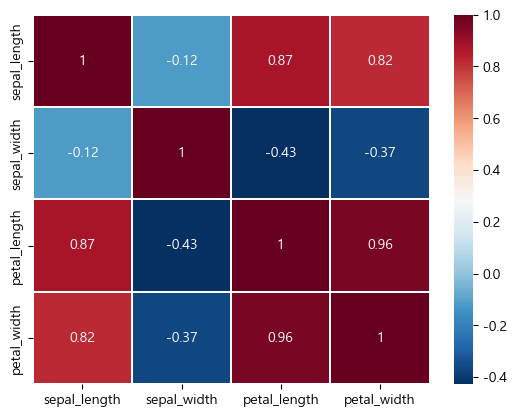

In [15]:
sns.heatmap(corr_matrix, annot=True, linewidths=0.1, cmap='RdBu_r')
plt.show()

In [16]:
r, p_value = stats.pearsonr( df['petal_length'], df['petal_width'] )
print(f"상관계수(r) = {r:.4f}")
print(f"p-value = {p_value:.2e}")
print(f"해석: {'차이가 있다' if p_value < 0.05 else '차이가 없다'}")

상관계수(r) = 0.9629
p-value = 4.68e-86
해석: 차이가 있다


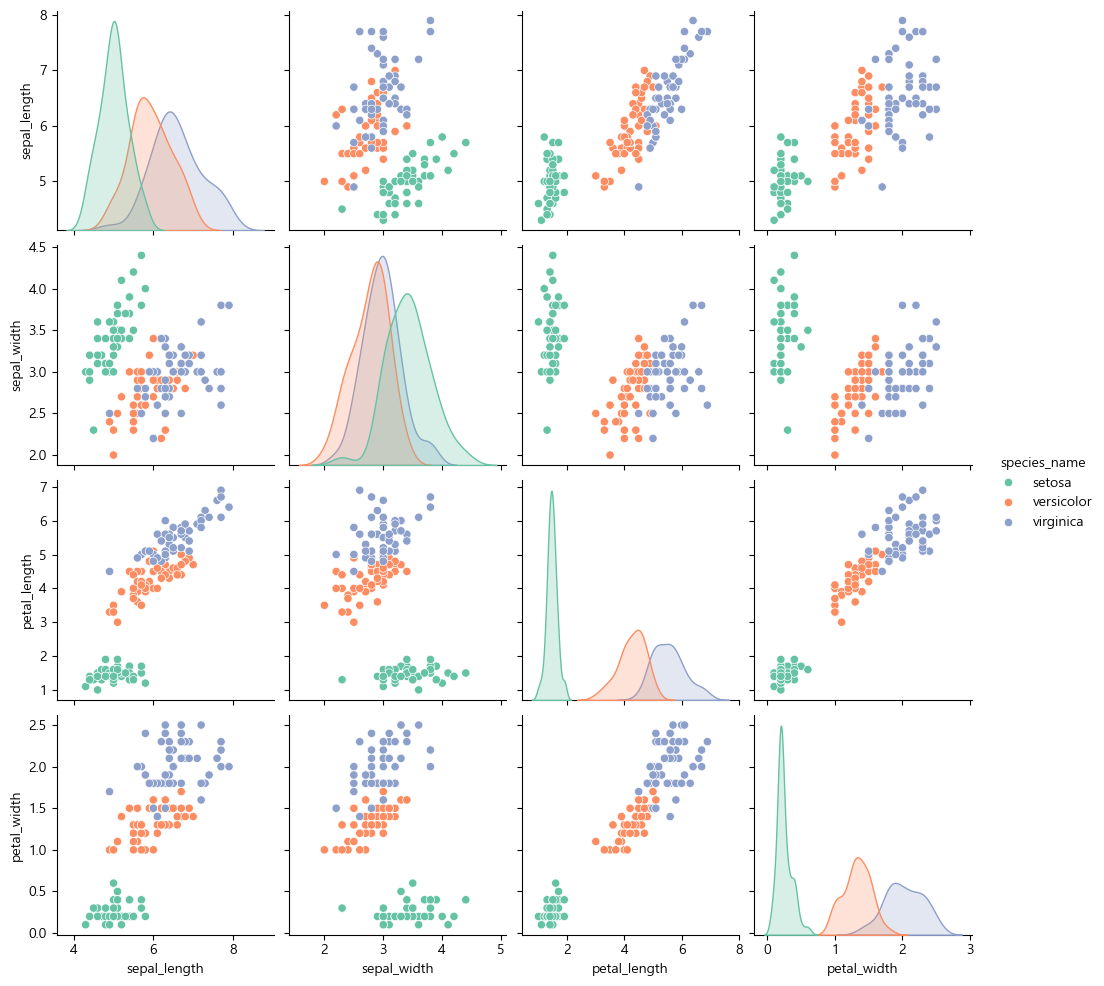

In [17]:
sns.pairplot(df, vars=numeric_cols, hue='species_name', palette='Set2')
plt.show()

In [18]:
setosa = df[ df['species_name'] == 'setosa' ]
versicolor = df[ df['species_name'] == 'versicolor' ]

In [19]:
setosa.shape, versicolor.shape

((50, 6), (50, 6))

In [20]:
for col in numeric_cols:
    print(col, stats.ttest_ind(setosa[col], versicolor[col]))
# p-value 모든 컬럼의 pvalue가 0.05 보다 작기 때문에 모든 컬럼은 차이가 있다.(대립가설 채택)

sepal_length TtestResult(statistic=-10.52098626754911, pvalue=8.985235037487147e-18, df=98.0)
sepal_width TtestResult(statistic=9.454975848128596, pvalue=1.845259945476927e-15, df=98.0)
petal_length TtestResult(statistic=-39.492719391538095, pvalue=5.404910513441767e-62, df=98.0)
petal_width TtestResult(statistic=-34.08034154357719, pvalue=3.831095388248143e-56, df=98.0)


In [21]:
two_species = df[ df['species_name'].isin( ['setosa', 'versicolor'] ) ]
two_species.shape

(100, 6)

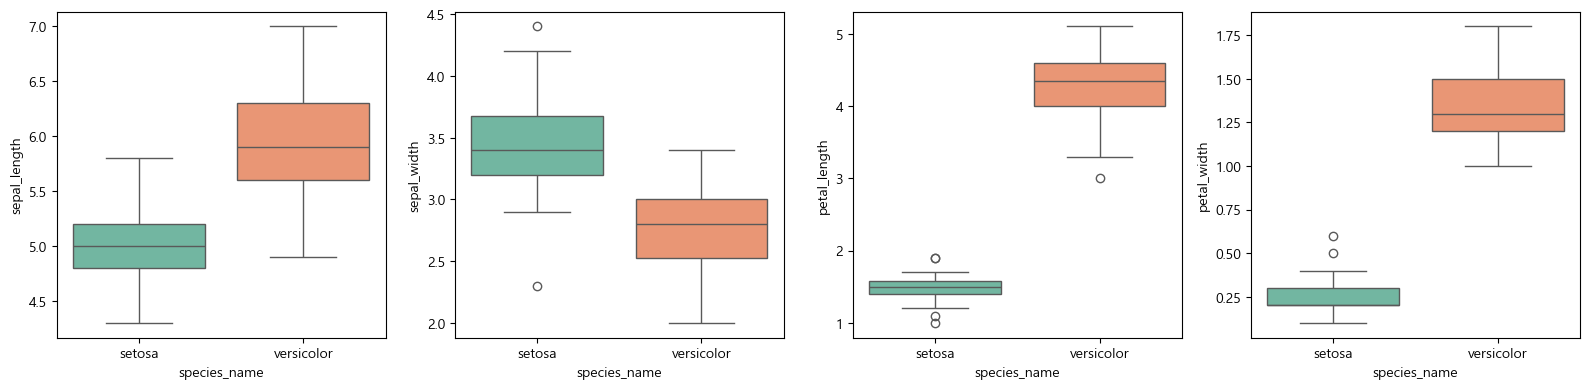

In [22]:
plt.figure(figsize=(16, 4))
for i, col in enumerate( numeric_cols, 1 ): # 1은 1부터 시작
    # print(i, col)
    plt.subplot(1, 4, i) # plt.subplot(1, 4, 1), plt.subplot(1, 4, 2), ...
    sns.boxplot(data=two_species, x='species_name', y=col, palette='Set2')
plt.tight_layout()
plt.show()

In [23]:
# ANOVA : 3개 이상의 그룹을 비교

In [24]:
hap = [ ] # 빈 리스트
for i in range(1, 6): # [1,2,3,4,5]
    # print(i)
    hap.append( i ** 2 )
print(hap)

[1, 4, 9, 16, 25]


In [25]:
# 리스트 표현식
hap2 = [ i ** 2 for i in range(1,6) ]
hap2

[1, 4, 9, 16, 25]

In [26]:
groups = [ df[ df['species_name'] == s ] for s in ['setosa','versicolor','virginica'] ]
len( groups )

3

In [27]:
setosa = df[ df['species_name'] == 'setosa' ]
versicolor = df[ df['species_name'] == 'versicolor' ]
virginica = df[ df['species_name'] == 'virginica' ]

In [28]:
print(df['species_name'].unique())
print(len(setosa), len(versicolor), len(virginica))

['setosa' 'versicolor' 'virginica']
50 50 50


In [29]:
for col in numeric_cols:
    print( col, stats.f_oneway(setosa[col], versicolor[col], virginica[col]) )
    # f_oneway(setosa['sepal_length'],versicolor['sepal_length'],virginica['sepal_length']

sepal_length F_onewayResult(statistic=119.26450218450468, pvalue=1.6696691907693826e-31)
sepal_width F_onewayResult(statistic=49.160040089612075, pvalue=4.492017133309084e-17)
petal_length F_onewayResult(statistic=1180.1611822529785, pvalue=2.8567766109619814e-91)
petal_width F_onewayResult(statistic=960.007146801809, pvalue=4.169445839443116e-85)


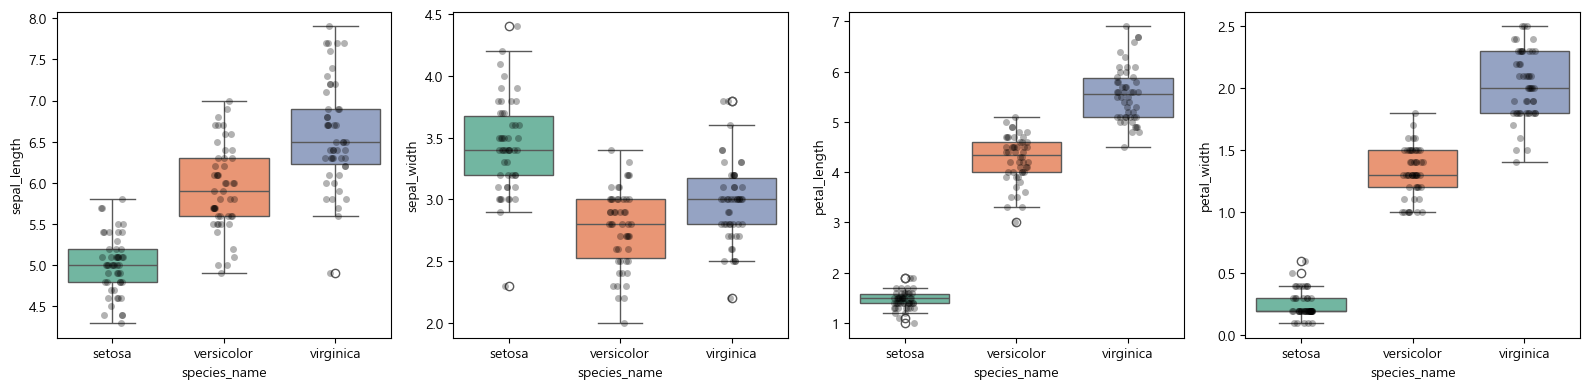

In [30]:
plt.figure(figsize=(16,4))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(1,4,i)
    sns.boxplot(df, x='species_name', y=col, palette='Set2')
    sns.stripplot(df, x='species_name', y=col, color='black', alpha=0.3)
plt.tight_layout()
plt.show()

In [31]:
# PCA(주성분 분석)

In [32]:
# mglearn 라이브러리가 없으면 설치하라.
try:
    import mglearn
except:
    ! pip install mglearn

In [33]:
import mglearn

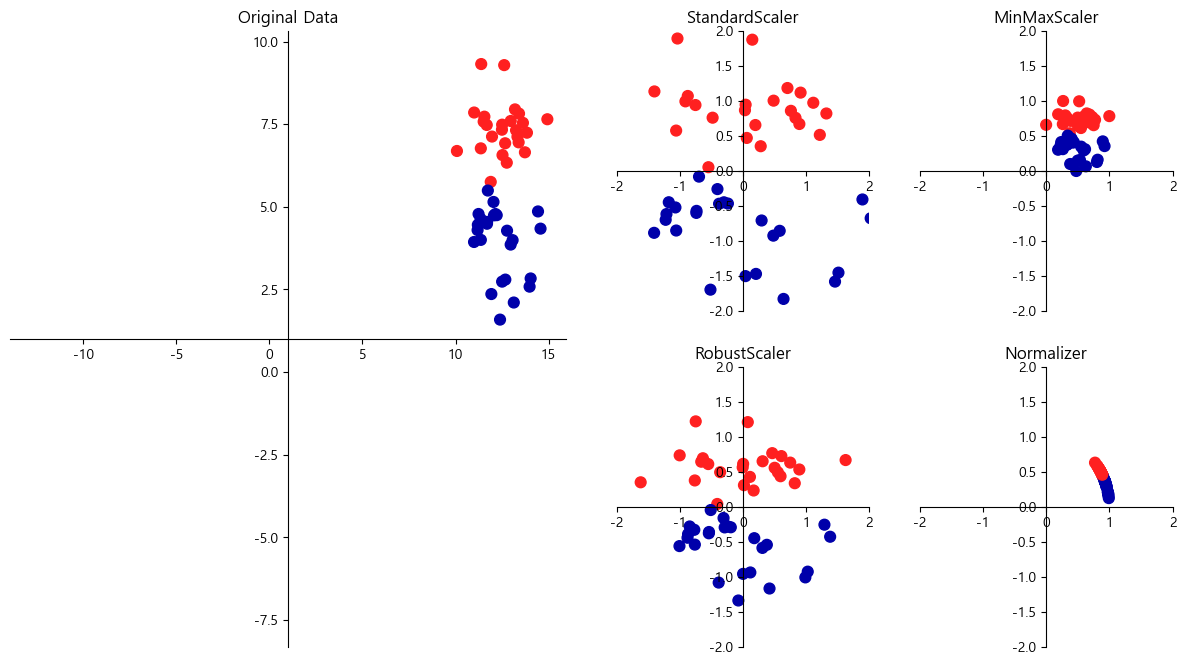

In [34]:
# 표준화(정규화) 그래프
mglearn.plots.plot_scaling()

In [36]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [38]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[numeric_cols])

In [41]:
print( df[numeric_cols].mean().values.round(2) )
print( X_scaled.mean(axis=0).round(2) ) # 평균 0
print( X_scaled.std(axis=0).round(2) )  # 표준편차 1

[5.84 3.06 3.76 1.2 ]
[-0. -0. -0. -0.]
[1. 1. 1. 1.]


In [42]:
pca = PCA()
pca.fit(X_scaled)

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",None
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized S

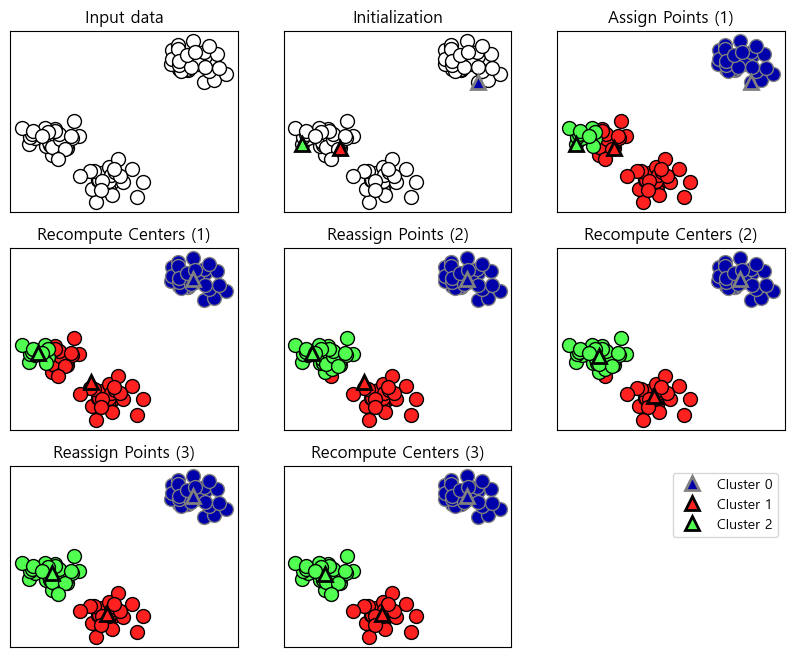

In [43]:
mglearn.plots.plot_kmeans_algorithm()

In [44]:
# end